# Phase 4 — Production SaaS Architecture for LLM Apps

**Use case: SummaryBot** — a fictional multi-tenant SaaS where companies pay to AI-summarise documents and schedule review meetings.  
**Why this use case?** It naturally exercises every production concern: multiple orgs sharing infrastructure, usage billing, auth, integrations, and resilience.

---

## What you will learn

| # | Topic | Concept |
|---|-------|---------|
| 1 | Usage Metering | Token cost tracking per user/org in SQLite |
| 2 | JWT Authentication | Stateless auth tokens and API key management |
| 3 | Multi-Tenancy | Isolating context and data per organisation |
| 4 | Resilient LLM Calls | Timeouts, fallback models, response caching |
| 5 | Streaming | SSE and `client.messages.stream()` |
| 6 | MCP Integration | Model Context Protocol — tools that call external APIs |
| 7 | Rate Limiting | Token bucket algorithm per user |
| 8 | Cost Dashboard | Multi-panel visualisation of spend |

> **Prerequisites:** Complete Phase 1–3 notebooks first. This notebook assumes you understand LLM API calls (Phase 1), agent tool_use (Phase 2), and async Python basics.

In [1]:
# Install all dependencies for this notebook
# PyJWT handles JWT signing — simpler than python-jose, no C extension required
%pip install -q anthropic pyjwt python-dotenv httpx matplotlib pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, sqlite3, asyncio, hashlib, secrets, time
from datetime import datetime, timezone, timedelta
from typing import Optional

import anthropic
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from dotenv import load_dotenv
import jwt  # PyJWT — use jwt.PyJWTError as the base exception class

# Load ANTHROPIC_API_KEY from the ARIA project .env
load_dotenv(dotenv_path="../.env")

client = anthropic.Anthropic()   # picks up key from env automatically
MODEL  = "claude-haiku-4-5-20251001"  # haiku: cheap and fast, ideal for metered SaaS

print(f"Client ready — model: {MODEL}")

Client ready — model: claude-haiku-4-5-20251001


---
## Part 1 — Usage Metering

### The prototype-to-production gap

In a prototype you make LLM calls and ignore cost. In production **every token has a price**, and you need to:
- Know which customer drove which spend (so you can bill them)
- Detect runaway usage before it destroys your margin
- Understand which *features* are expensive (summarisation vs Q&A vs drafting)

### SummaryBot schema

```
┌──────────────────────────────────────────────────────────────────┐
│  Table: orgs                         Table: usage_logs           │
│  ─────────────────────               ──────────────────────────  │
│  id          TEXT PK                 id            INTEGER PK    │
│  name        TEXT                    org_id        TEXT  FK→orgs │
│  plan        TEXT (free/pro/ent)     user_id       TEXT          │
│  created_at  TEXT                    feature       TEXT          │
│                                      model         TEXT          │
│                                      input_tokens  INTEGER       │
│                                      output_tokens INTEGER       │
│                                      cost_usd      REAL          │
│                                      created_at    TEXT          │
└──────────────────────────────────────────────────────────────────┘
```

### Cost formula

Anthropic pricing (per million tokens, as of early 2025):
```
haiku:   input $0.80 / output $4.00  (per 1M tokens)
sonnet:  input $3.00 / output $15.00
opus:    input $15.0 / output $75.00

cost = (input_tokens / 1_000_000) * input_price
     + (output_tokens / 1_000_000) * output_price
```

> **Python analogy:** Think of `usage_logs` as a Django model with one row per API call. Billing runs a `GROUP BY org_id` query at month-end.

In [3]:
# In-memory SQLite database — change ":memory:" to a file path to persist
DB_PATH = ":memory:"

def get_db() -> sqlite3.Connection:
    """Return a connection to the usage database."""
    conn = sqlite3.connect(DB_PATH, check_same_thread=False)
    conn.row_factory = sqlite3.Row  # so rows behave like dicts
    return conn

# Global connection — reuse for this notebook session
_DB = get_db()

def init_db():
    """Create tables if they don't exist. Safe to call multiple times."""
    with _DB:
        _DB.executescript("""
            CREATE TABLE IF NOT EXISTS orgs (
                id         TEXT PRIMARY KEY,
                name       TEXT NOT NULL,
                plan       TEXT NOT NULL DEFAULT 'free',
                created_at TEXT NOT NULL DEFAULT (datetime('now'))
            );

            CREATE TABLE IF NOT EXISTS usage_logs (
                id            INTEGER PRIMARY KEY AUTOINCREMENT,
                org_id        TEXT    NOT NULL REFERENCES orgs(id),
                user_id       TEXT    NOT NULL,
                feature       TEXT    NOT NULL,
                model         TEXT    NOT NULL,
                input_tokens  INTEGER NOT NULL DEFAULT 0,
                output_tokens INTEGER NOT NULL DEFAULT 0,
                cost_usd      REAL    NOT NULL DEFAULT 0.0,
                created_at    TEXT    NOT NULL DEFAULT (datetime('now'))
            );
        """)

    # Seed two demo organisations
    with _DB:
        _DB.executemany(
            "INSERT OR IGNORE INTO orgs (id, name, plan) VALUES (?, ?, ?)",
            [
                ("org_acme",    "Acme Corp",      "pro"),
                ("org_globex",  "Globex Inc",     "enterprise"),
            ]
        )

    print("Database initialised ✅")
    orgs = _DB.execute("SELECT id, name, plan FROM orgs").fetchall()
    for o in orgs:
        print(f"  org: {o['id']}  ({o['name']}, plan={o['plan']})")

init_db()

Database initialised ✅
  org: org_acme  (Acme Corp, plan=pro)
  org: org_globex  (Globex Inc, plan=enterprise)


In [4]:
# ── Pricing table ─────────────────────────────────────────────────────────
# Prices are per million tokens (input, output)
PRICING = {
    "claude-haiku-4-5-20251001":   {"input": 0.80,  "output": 4.00},
    "claude-sonnet-4-6":           {"input": 3.00,  "output": 15.00},
    "claude-opus-4-5":             {"input": 15.00, "output": 75.00},
}

def compute_cost(model: str, input_tokens: int, output_tokens: int) -> float:
    """Calculate cost in USD for a single LLM call."""
    prices = PRICING.get(model, {"input": 3.00, "output": 15.00})  # default to sonnet
    return (
        (input_tokens  / 1_000_000) * prices["input"] +
        (output_tokens / 1_000_000) * prices["output"]
    )

def log_usage(org_id: str, user_id: str, feature: str,
              model: str, input_tokens: int, output_tokens: int):
    """Write one row to usage_logs after an LLM call completes."""
    cost = compute_cost(model, input_tokens, output_tokens)
    with _DB:
        _DB.execute(
            """INSERT INTO usage_logs
               (org_id, user_id, feature, model, input_tokens, output_tokens, cost_usd)
               VALUES (?, ?, ?, ?, ?, ?, ?)""",
            (org_id, user_id, feature, model, input_tokens, output_tokens, cost)
        )
    return cost

def metered_call(prompt: str, org_id: str, user_id: str, feature: str) -> str:
    """
    Wrapper around client.messages.create() that automatically logs usage.
    This is the only function your app code should call — never the raw client directly.
    """
    response = client.messages.create(
        model=MODEL,
        max_tokens=200,
        messages=[{"role": "user", "content": prompt}]
    )

    # response.usage has .input_tokens and .output_tokens from the API
    cost = log_usage(
        org_id=org_id,
        user_id=user_id,
        feature=feature,
        model=MODEL,
        input_tokens=response.usage.input_tokens,
        output_tokens=response.usage.output_tokens,
    )

    print(f"[{org_id}/{user_id}] feature={feature}  "
          f"in={response.usage.input_tokens} out={response.usage.output_tokens}  "
          f"cost=${cost:.6f}")
    return response.content[0].text


# ── Demo: 3 users across 2 orgs use different features ───────────────────
print("=== Simulating SummaryBot usage ===\n")

metered_call(
    prompt="Summarise in one sentence: The quick brown fox jumps over the lazy dog.",
    org_id="org_acme", user_id="alice", feature="summarise"
)
metered_call(
    prompt="Draft a subject line for a document review meeting about Q3 financials.",
    org_id="org_acme", user_id="bob", feature="draft_subject"
)
metered_call(
    prompt="What are the key action items in: Bob needs to review Q3 report by Friday.",
    org_id="org_globex", user_id="carol", feature="extract_actions"
)
metered_call(
    prompt="Summarise in one sentence: Globex quarterly revenue exceeded expectations.",
    org_id="org_globex", user_id="carol", feature="summarise"
)
metered_call(
    prompt="Summarise in one sentence: The board approved the new product roadmap.",
    org_id="org_acme", user_id="alice", feature="summarise"
)

# Print the raw log
print("\n=== Raw usage_logs ===")
rows = _DB.execute(
    "SELECT org_id, user_id, feature, input_tokens, output_tokens, cost_usd FROM usage_logs"
).fetchall()
for r in rows:
    print(dict(r))

=== Simulating SummaryBot usage ===

[org_acme/alice] feature=summarise  in=25 out=14  cost=$0.000076
[org_acme/bob] feature=draft_subject  in=23 out=118  cost=$0.000490
[org_globex/carol] feature=extract_actions  in=26 out=95  cost=$0.000401
[org_globex/carol] feature=summarise  in=22 out=15  cost=$0.000078
[org_acme/alice] feature=summarise  in=23 out=14  cost=$0.000074

=== Raw usage_logs ===
{'org_id': 'org_acme', 'user_id': 'alice', 'feature': 'summarise', 'input_tokens': 25, 'output_tokens': 14, 'cost_usd': 7.6e-05}
{'org_id': 'org_acme', 'user_id': 'bob', 'feature': 'draft_subject', 'input_tokens': 23, 'output_tokens': 118, 'cost_usd': 0.0004904}
{'org_id': 'org_globex', 'user_id': 'carol', 'feature': 'extract_actions', 'input_tokens': 26, 'output_tokens': 95, 'cost_usd': 0.00040080000000000004}
{'org_id': 'org_globex', 'user_id': 'carol', 'feature': 'summarise', 'input_tokens': 22, 'output_tokens': 15, 'cost_usd': 7.76e-05}
{'org_id': 'org_acme', 'user_id': 'alice', 'feature': 

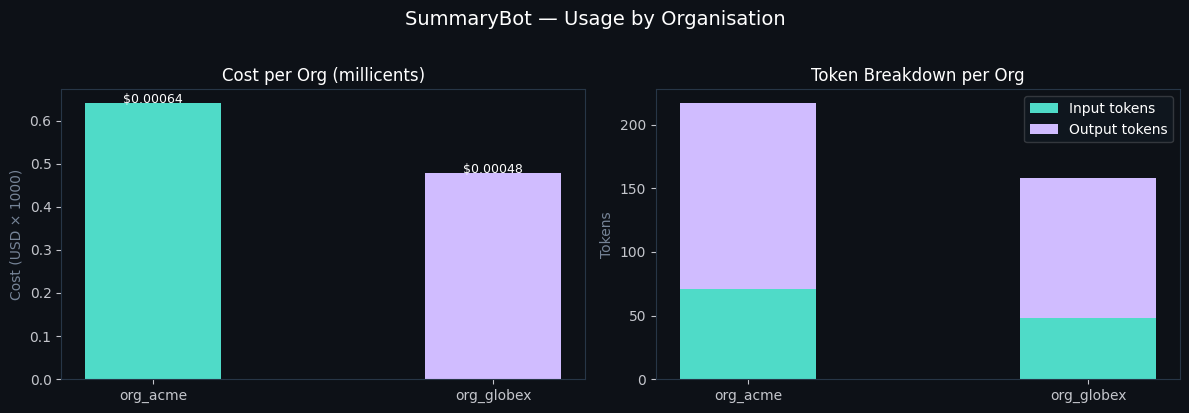

    org_id  total_cost  input_tok  output_tok  calls
  org_acme    0.000641         71         146      3
org_globex    0.000478         48         110      2


In [5]:
# ── Cost breakdown by org — bar chart ────────────────────────────────────
df = pd.read_sql_query(
    "SELECT org_id, SUM(cost_usd) as total_cost, SUM(input_tokens) as input_tok, "
    "SUM(output_tokens) as output_tok, COUNT(*) as calls FROM usage_logs GROUP BY org_id",
    _DB
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#0d1117")
fig.suptitle("SummaryBot — Usage by Organisation", color="white", fontsize=14, y=1.02)

COLORS = ["#4fdbc8", "#d0bcff", "#f59e0b", "#34d399"]

# Left: total cost per org
ax = axes[0]
ax.set_facecolor("#0d1117")
bars = ax.bar(df["org_id"], df["total_cost"] * 1000, color=COLORS[:len(df)], width=0.4)
ax.set_title("Cost per Org (millicents)", color="white")
ax.set_ylabel("Cost (USD × 1000)", color="#768497")
ax.tick_params(colors="#c4c6cc")
for spine in ax.spines.values(): spine.set_color("#273647")
for bar, val in zip(bars, df["total_cost"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"${val:.5f}", ha="center", color="white", fontsize=9)

# Right: token split (input vs output) stacked bar
ax2 = axes[1]
ax2.set_facecolor("#0d1117")
ax2.bar(df["org_id"], df["input_tok"],  label="Input tokens",  color="#4fdbc8", width=0.4)
ax2.bar(df["org_id"], df["output_tok"], label="Output tokens", color="#d0bcff", width=0.4,
        bottom=df["input_tok"])
ax2.set_title("Token Breakdown per Org", color="white")
ax2.set_ylabel("Tokens", color="#768497")
ax2.tick_params(colors="#c4c6cc")
for spine in ax2.spines.values(): spine.set_color("#273647")
ax2.legend(labelcolor="white", framealpha=0.2, facecolor="#1c2b3c")

plt.tight_layout()
plt.show()
print(df.to_string(index=False))

---
## Part 2 — JWT Authentication

### JWT vs API Keys — when to use each

| | JWT (JSON Web Token) | API Key |
|-|-|-|
| **What it is** | A signed JSON payload (header.payload.signature) | A long random string |
| **Contains claims** | Yes — user_id, org_id, expiry are *inside* the token | No — server must look up the database |
| **Stateless** | Yes — server can verify with just the secret, no DB hit | No — must query DB to validate |
| **Revocable** | Only after expiry (or with a blocklist) | Immediately, by deleting the row |
| **Best for** | User sessions, short-lived auth (hours) | Machine-to-machine, CI, long-lived integrations |
| **In SummaryBot** | Issued when a user logs in via the web UI | Issued once to integrate with CI pipelines |

```
JWT structure:
──────────────────────────────────────────────────────
  eyJhbGciOiJIUzI1NiJ9   ← Header  (base64: {"alg":"HS256"})
  .eyJ1c2VyX2lkIjoiYWxpY2UiLCAib3JnX2lkIjoib3JnX2FjbWUifQ==   ← Payload
  .SflKxwRJSMeKKF2QT4fwpMeJf36POk6yJV_adQssw5c   ← Signature
──────────────────────────────────────────────────────
Server verifies: HMAC-SHA256(header + "." + payload, SECRET) == signature
If yes → trust the claims. If no → reject.
```

> **Python analogy:** Think of a JWT like a signed session cookie in Django — the server doesn't store it, but it can verify it was issued by you because only you know the secret key.

In [6]:
# ── JWT helpers (using PyJWT) ────────────────────────────────────────────
JWT_SECRET    = "summarybot-demo-secret-change-in-prod"  # use secrets.token_hex(32) in production
JWT_ALGORITHM = "HS256"
JWT_EXPIRE_MINUTES = 60  # tokens expire after 1 hour

def create_access_token(user_id: str, org_id: str,
                         expire_minutes: int = JWT_EXPIRE_MINUTES) -> str:
    """Issue a JWT containing user_id and org_id claims."""
    now     = datetime.now(timezone.utc)
    payload = {
        "sub":    user_id,          # 'subject' — standard JWT claim
        "org_id": org_id,
        "iat":    now,              # issued-at
        "exp":    now + timedelta(minutes=expire_minutes),  # expiry
    }
    return jwt.encode(payload, JWT_SECRET, algorithm=JWT_ALGORITHM)

def verify_token(token: str) -> dict:
    """
    Decode and verify a JWT. Raises JWTError on invalid/expired tokens.
    Returns the claims dict on success.
    """
    try:
        claims = jwt.decode(token, JWT_SECRET, algorithms=[JWT_ALGORITHM])
        return {"valid": True, "user_id": claims["sub"], "org_id": claims["org_id"]}
    except jwt.PyJWTError as e:
        return {"valid": False, "error": str(e)}

def generate_api_key() -> str:
    """
    Generate a cryptographically random API key.
    The 'sb_' prefix makes it identifiable if accidentally leaked.
    """
    return "sb_" + secrets.token_urlsafe(32)


# ── Demo: issue, verify, and reject an expired token ─────────────────────
print("=== JWT Demo ===\n")

# 1. Issue a valid token for alice@acme
token = create_access_token(user_id="alice", org_id="org_acme")
print(f"Issued token (first 60 chars):\n  {token[:60]}...\n")

# 2. Verify the token — should succeed
result = verify_token(token)
print(f"Verify valid token:  {result}")

# 3. Verify a tampered token — should fail
bad_token = token[:-4] + "XXXX"  # corrupt the signature
print(f"Verify tampered token: {verify_token(bad_token)}")

# 4. Issue a token that expires immediately and verify it
expired = create_access_token("alice", "org_acme", expire_minutes=-1)  # already expired
print(f"Verify expired token:  {verify_token(expired)}")

# 5. Generate an API key
api_key = generate_api_key()
print(f"\nGenerated API key: {api_key}")

=== JWT Demo ===

Issued token (first 60 chars):
  eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJzdWIiOiJhbGljZSIsIm9...

Verify valid token:  {'valid': True, 'user_id': 'alice', 'org_id': 'org_acme'}
Verify tampered token: {'valid': False, 'error': 'Signature verification failed'}
Verify expired token:  {'valid': False, 'error': 'Signature has expired'}

Generated API key: sb_o2hiiQi8LuEA6_iIhysjPyvPmhxgrY59jKgL_CvaaoQ


---
## Part 3 — Multi-Tenancy

### The isolation problem

SummaryBot serves multiple companies (orgs). The most dangerous mistake is **context bleed** — one org's data leaking into another org's responses.

```
WRONG — shared global state:
──────────────────────────────────────────────────────────
  system_prompt = "You work for {last_org_that_called}"   ← race condition!
  conversation_history = []                               ← shared across users!

RIGHT — isolated per request:
──────────────────────────────────────────────────────────
  ORG_CONTEXTS[org_id]["system_prompt"]    ← keyed by org
  ORG_CONTEXTS[org_id]["conversation"]     ← keyed by org (and ideally by user)
──────────────────────────────────────────────────────────
```

**Three isolation layers in a production multi-tenant LLM app:**

| Layer | What it isolates | How |
|-------|-----------------|-----|
| **System prompt** | Persona, data scope, tone | Different prompt per org in `ORG_CONTEXTS` dict |
| **Conversation history** | Prior turns in a session | Store per `(org_id, user_id, session_id)` key |
| **Database rows** | Stored documents, logs | `WHERE org_id = ?` on every query |

> **Python analogy:** Think of each org as a separate Django `Site` object — same code, but all queries are scoped to that site's data.

In [7]:
# ── Org-specific context store ────────────────────────────────────────────
# In production this might come from a database row keyed on org_id.
# Here it's a dict — the principle is identical.

ORG_CONTEXTS = {
    "org_acme": {
        "name": "Acme Corp",
        "system_prompt": (
            "You are SummaryBot for Acme Corp, a manufacturing company. "
            "Acme's internal style is formal and concise. "
            "Always refer to documents as 'reports' and meetings as 'reviews'. "
            "Never reveal details about other organisations."
        ),
        "tone": "formal",
    },
    "org_globex": {
        "name": "Globex Inc",
        "system_prompt": (
            "You are SummaryBot for Globex Inc, a technology startup. "
            "Globex's style is casual and emoji-friendly. "
            "Always refer to documents as 'docs' and meetings as 'syncs'. "
            "Never reveal details about other organisations."
        ),
        "tone": "casual",
    },
}


def ask_with_tenant_context(question: str, user_id: str, org_id: str) -> str:
    """
    Ask a question in the context of a specific org.
    Each call is isolated — no state is shared between orgs.
    """
    if org_id not in ORG_CONTEXTS:
        raise ValueError(f"Unknown org: {org_id}")

    ctx = ORG_CONTEXTS[org_id]

    response = client.messages.create(
        model=MODEL,
        max_tokens=150,
        system=ctx["system_prompt"],   # org-specific persona injected here
        messages=[{"role": "user", "content": question}]
    )

    answer = response.content[0].text
    print(f"[{org_id}/{user_id}] (tone={ctx['tone']})")
    print(f"  Q: {question}")
    print(f"  A: {answer}\n")
    return answer


# ── Demo: same question, two orgs, org-appropriate answers ────────────────
SHARED_QUESTION = "Please help me schedule a document review for next Tuesday."

print("=== Same question, two orgs, different personas ===\n")
ask_with_tenant_context(SHARED_QUESTION, user_id="alice", org_id="org_acme")
ask_with_tenant_context(SHARED_QUESTION, user_id="carol", org_id="org_globex")

=== Same question, two orgs, different personas ===

[org_acme/alice] (tone=formal)
  Q: Please help me schedule a document review for next Tuesday.
  A: I'd be happy to help you schedule a document review for next Tuesday.

To proceed, I'll need a few details:

1. **Specific date** – Which Tuesday are you referring to? (Please provide the date)
2. **Time** – What time would you prefer?
3. **Participants** – Who should be included in this review?
4. **Report details** – Which report requires review?
5. **Duration** – How long do you anticipate the review will take?

Once you provide these details, I can assist you in scheduling the review.

[org_globex/carol] (tone=casual)
  Q: Please help me schedule a document review for next Tuesday.
  A: Hey! 👋 I'd love to help you get that doc review scheduled for next Tuesday!

To nail down the details, I just need a few quick things:

⏰ **What time works best for you?**
📋 **Which doc(s) are we reviewing?** (just the name or topic is fine!)
👥 **W

"Hey! 👋 I'd love to help you get that doc review scheduled for next Tuesday!\n\nTo nail down the details, I just need a few quick things:\n\n⏰ **What time works best for you?**\n📋 **Which doc(s) are we reviewing?** (just the name or topic is fine!)\n👥 **Who else should be in on this?** (just let me know names or teams)\n\nOnce I've got those details, I can help you get it on everyone's calendar! 🎯"

---
## Part 4 — Resilient LLM Calls

### Failure modes and strategies

LLM APIs are third-party HTTP services. They fail in ways your own code doesn't:

| Failure mode | When it happens | Strategy |
|-------------|----------------|----------|
| **Timeout** | Long prompts, network congestion | `asyncio.wait_for` with deadline |
| **Overload (529)** | Anthropic rate limits your key | Exponential backoff with jitter |
| **Model unavailable** | Maintenance, regional outage | Fallback to a different model |
| **Token limit exceeded** | Prompt is too long | Truncate input, or switch to longer-context model |
| **Repeated identical calls** | Same prompt from multiple users | Cache by prompt hash + TTL |

```
Resilience stack (outermost to innermost):
──────────────────────────────────────────────────────
  ┌─ check cache ──────────────────────────────────┐
  │  ┌─ timeout guard ──────────────────────────┐  │
  │  │  ┌─ retry with backoff ──────────────┐   │  │
  │  │  │  ┌─ fallback model ────────────┐  │   │  │
  │  │  │  │   actual API call           │  │   │  │
  │  │  │  └────────────────────────────┘  │   │  │
  │  │  └──────────────────────────────────┘   │  │
  │  └──────────────────────────────────────────┘  │
  └────────────────────────────────────────────────┘
──────────────────────────────────────────────────────
```

In [8]:
import asyncio

# ── 1. Timeout guard ──────────────────────────────────────────────────────
async def call_with_timeout(prompt: str, timeout_sec: float = 5.0) -> str:
    """
    Wraps the synchronous Anthropic client in a thread so asyncio can
    apply a timeout to it. asyncio.wait_for cancels the task if it exceeds
    the deadline, raising asyncio.TimeoutError.
    """
    loop = asyncio.get_event_loop()

    # run_in_executor lets you await a blocking function in an async context
    def _sync_call():
        resp = client.messages.create(
            model=MODEL, max_tokens=100,
            messages=[{"role": "user", "content": prompt}]
        )
        return resp.content[0].text

    try:
        result = await asyncio.wait_for(
            loop.run_in_executor(None, _sync_call),
            timeout=timeout_sec
        )
        return result
    except asyncio.TimeoutError:
        return f"[TIMEOUT] Call exceeded {timeout_sec}s budget"


# ── 2. Fallback model ─────────────────────────────────────────────────────
FALLBACK_MODEL = "claude-haiku-4-5-20251001"  # cheaper/faster backup
PRIMARY_MODEL  = "claude-haiku-4-5-20251001"  # in reality you'd try sonnet first

def call_with_fallback(prompt: str) -> tuple[str, str]:
    """
    Try primary model first; fall back to a cheaper model on error.
    Returns (answer, model_used) so the caller knows which model responded.
    """
    for model in [PRIMARY_MODEL, FALLBACK_MODEL]:
        try:
            resp = client.messages.create(
                model=model, max_tokens=100,
                messages=[{"role": "user", "content": prompt}]
            )
            return resp.content[0].text, model
        except Exception as e:
            print(f"  [{model}] failed: {e} — trying fallback")
    return "[ERROR] All models failed", "none"


# ── 3. TTL cache keyed by prompt hash ─────────────────────────────────────
_CACHE: dict[str, dict] = {}  # {sha256_key: {"response": str, "expires_at": float}}
CACHE_TTL_SECONDS = 300       # 5 minutes

def cached_call(prompt: str) -> tuple[str, bool]:
    """
    Return a cached response if available and not expired.
    Returns (answer, cache_hit: bool).
    The cache key is SHA-256 of the exact prompt — so even one character
    difference misses the cache (intentional — different prompts = different intent).
    """
    key = hashlib.sha256(prompt.encode()).hexdigest()
    now = time.time()

    if key in _CACHE and _CACHE[key]["expires_at"] > now:
        return _CACHE[key]["response"], True  # cache hit

    # Cache miss — call the API and store the result
    resp = client.messages.create(
        model=MODEL, max_tokens=100,
        messages=[{"role": "user", "content": prompt}]
    )
    answer = resp.content[0].text
    _CACHE[key] = {"response": answer, "expires_at": now + CACHE_TTL_SECONDS}
    return answer, False  # cache miss


# ── Demo all three ─────────────────────────────────────────────────────────
print("=== Resilience Demo ===\n")

# Timeout (generous limit — this will succeed in normal conditions)
answer = asyncio.run(call_with_timeout("What is 2+2?", timeout_sec=30.0))
print(f"Timeout call result:  {answer!r}")

# Fallback model
answer, used_model = call_with_fallback("What is the capital of France?")
print(f"\nFallback call result: {answer!r}  (model used: {used_model})")

# Cache demo — second call should be instant and show cache_hit=True
PROMPT = "Summarise in 5 words: The quick brown fox jumps over the lazy dog."
ans1, hit1 = cached_call(PROMPT)
ans2, hit2 = cached_call(PROMPT)  # exact same prompt
print(f"\nCache miss: {ans1!r}  (hit={hit1})")
print(f"Cache hit:  {ans2!r}  (hit={hit2})")

=== Resilience Demo ===



RuntimeError: asyncio.run() cannot be called from a running event loop

---
## Part 5 — Streaming

### What is SSE (Server-Sent Events)?

By default, an LLM call blocks until the **complete** response is ready — users see nothing for 2–5 seconds, then the whole answer appears at once. **Streaming** sends tokens as they are generated:

```
Without streaming:          With streaming (SSE):
──────────────────          ──────────────────────
 user sends request          user sends request
 [........... 3s ........]   ["The"]  → render
 whole answer arrives        [" quick"] → render
                             [" brown"] → render
                             ...tokens arrive as generated
```

SSE is a standard HTTP pattern: the server sends a stream of `data: ...\n\n` lines, and the browser/client processes each line as it arrives.

**In a FastAPI app** you would wrap this in `StreamingResponse`:
```python
# FastAPI pattern (not runnable here — shown for reference)
from fastapi.responses import StreamingResponse

async def sse_generator(prompt: str):
    with client.messages.stream(model=MODEL, ...) as stream:
        for text in stream.text_stream:
            yield f"data: {json.dumps({'token': text})}\\n\\n"

@app.get("/stream")
async def stream_endpoint(prompt: str):
    return StreamingResponse(sse_generator(prompt), media_type="text/event-stream")
```
The `client.messages.stream()` call you'll use below is identical to what goes inside `sse_generator`.

In [9]:
# ── Streaming demo using Anthropic's context manager ─────────────────────
# client.messages.stream() returns a context manager.
# stream.text_stream is a generator that yields one string chunk per token.

STREAMING_PROMPT = (
    "Write a 3-sentence summary of why streaming responses improve user experience "
    "in chat applications. Be specific."
)

print("=== Streaming response (tokens arrive one by one) ===\n")
print("[START]  ", end="", flush=True)

with client.messages.stream(
    model=MODEL,
    max_tokens=200,
    messages=[{"role": "user", "content": STREAMING_PROMPT}]
) as stream:
    for text_chunk in stream.text_stream:
        # In a real app: yield f"data: {json.dumps({'token': text_chunk})}\n\n"
        # Here: print each chunk as it arrives to simulate the streaming effect
        print(text_chunk, end="", flush=True)

    # stream.get_final_message() is available after the loop —
    # it contains the complete message with token counts
    final = stream.get_final_message()

print("  [END]\n")
print(f"Token usage: input={final.usage.input_tokens}  output={final.usage.output_tokens}")
print(f"Cost: ${compute_cost(MODEL, final.usage.input_tokens, final.usage.output_tokens):.6f}")

=== Streaming response (tokens arrive one by one) ===

[START]  # Streaming Responses in Chat Applications

Streaming responses reduce perceived latency by displaying text progressively as it's generated, rather than forcing users to wait for a complete response before seeing anything. This creates a sense of immediacy and responsiveness that makes interactions feel faster and more natural, similar to human conversation. Additionally, streaming allows users to begin reading and processing information immediately while the application continues generating the rest, enabling faster comprehension and reducing the frustration of blank screens during long response generation.  [END]

Token usage: input=28  output=104
Cost: $0.000438


---
## Part 6 — MCP Integration

### What is MCP (Model Context Protocol)?

MCP is a standard protocol that lets LLMs call **external tools** through a structured interface. It extends the `tool_use` pattern you learned in Phase 2 — the difference is that instead of you writing the tool handler inline, there's a **separate MCP server** that handles the execution:

```
Phase 2 (inline tools):          Phase 4 (MCP):
───────────────────────          ──────────────────────────────────────────
  LLM                              LLM
   │ tool_use block                 │ tool_use block
   ▼                                ▼
  your code (handler fn)          your code (MCP client)
   │ runs the function              │ HTTP/stdio call
   │ returns result                 ▼
   └──► back to LLM               MCP Server (e.g. gmail-mcp)
                                    │ calls Gmail API with OAuth token
                                    │ returns structured result
                                    └──► your code ──► back to LLM
───────────────────────────────────────────────────────────────────────────
```

**Why MCP instead of calling Gmail directly?**
- Reusable: one MCP server can be used by many LLM apps
- Sandboxed: the LLM can only do what the MCP server exposes
- Composable: chain multiple MCP servers (Gmail + Calendar + Slack)
- Auth is handled by the MCP server, not your app code

### Gmail MCP and Google Calendar MCP

**Gmail MCP** exposes tools like:
- `draft_email(to, subject, body)` — create a draft in the user's Gmail
- `send_email(to, subject, body)` — send immediately
- `search_emails(query)` — search inbox

**Google Calendar MCP** exposes tools like:
- `create_event(title, start_time, end_time, attendees)` — create a calendar event
- `list_events(date_range)` — fetch upcoming events
- `find_free_slots(attendees, duration)` — check availability

**Authentication flow (OAuth 2.0):**
```
1. User visits SummaryBot's /auth/google endpoint
2. They are redirected to Google's OAuth consent screen
3. After consent, Google issues an access_token + refresh_token
4. SummaryBot stores the refresh_token (encrypted) against the user's org_id
5. On each MCP call, the server retrieves the token and calls the Google API
```

**In the notebook below:** We simulate the full ReAct loop with fake MCP tool handlers — the tool definitions are real Anthropic tool_use format, and Claude decides when to call them. Only the actual HTTP call to the MCP server is replaced with a print statement.

In [10]:
# ── Simulated MCP tool definitions (real Anthropic tool_use format) ───────
MCP_TOOLS = [
    {
        "name": "draft_email",
        "description": (
            "Create a draft email in the user's Gmail. "
            "Use this when the user wants to notify stakeholders about a document summary."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "to":      {"type": "string",  "description": "Recipient email address"},
                "subject": {"type": "string",  "description": "Email subject line"},
                "body":    {"type": "string",  "description": "Full email body text"},
            },
            "required": ["to", "subject", "body"]
        }
    },
    {
        "name": "create_calendar_event",
        "description": (
            "Create a Google Calendar event. "
            "Use this when the user wants to schedule a document review meeting."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "title":     {"type": "string", "description": "Event title"},
                "date":      {"type": "string", "description": "Date in YYYY-MM-DD format"},
                "time":      {"type": "string", "description": "Start time in HH:MM format (24h)"},
                "duration":  {"type": "integer","description": "Duration in minutes"},
                "attendees": {"type": "array",  "items": {"type": "string"},
                              "description": "List of attendee email addresses"},
            },
            "required": ["title", "date", "time", "duration"]
        }
    }
]


# ── Simulated MCP server handlers ─────────────────────────────────────────
# In production these would be HTTP calls to the Gmail/Calendar MCP server.
# Here they just print what the MCP server WOULD do.

def handle_draft_email(inputs: dict) -> str:
    """Simulates: POST https://gmail-mcp.example.com/draft"""
    print(f"  [Gmail MCP] Draft created:")
    print(f"    To: {inputs['to']}")
    print(f"    Subject: {inputs['subject']}")
    print(f"    Body preview: {inputs['body'][:80]}...")
    return json.dumps({"status": "ok", "draft_id": "draft_abc123", "message": "Draft saved to Gmail"})

def handle_create_calendar_event(inputs: dict) -> str:
    """Simulates: POST https://calendar-mcp.example.com/events"""
    attendees = inputs.get("attendees", [])
    print(f"  [Calendar MCP] Event created:")
    print(f"    Title: {inputs['title']}")
    print(f"    When: {inputs['date']} at {inputs['time']} ({inputs['duration']} min)")
    print(f"    Attendees: {attendees}")
    return json.dumps({"status": "ok", "event_id": "cal_xyz789",
                       "message": f"Event scheduled for {inputs['date']} at {inputs['time']}"})

MCP_HANDLERS = {
    "draft_email":           handle_draft_email,
    "create_calendar_event": handle_create_calendar_event,
}


# ── ReAct loop with MCP tools ─────────────────────────────────────────────
def run_mcp_agent(user_request: str, org_id: str, user_id: str,
                   max_iterations: int = 5) -> str:
    """
    Full ReAct loop that uses MCP tools.
    Same pattern as Phase 2 — Claude decides when to call tools.
    """
    messages = [{"role": "user", "content": user_request}]
    system   = ORG_CONTEXTS.get(org_id, {}).get("system_prompt", "You are SummaryBot.")

    for iteration in range(max_iterations):
        print(f"\n--- Iteration {iteration + 1} ---")

        response = client.messages.create(
            model=MODEL,
            max_tokens=500,
            system=system,
            tools=MCP_TOOLS,
            messages=messages,
        )

        print(f"stop_reason: {response.stop_reason}")

        if response.stop_reason == "end_turn":
            # Claude is done — extract and return the final text
            for block in response.content:
                if hasattr(block, "text"):
                    return block.text
            return "Done (no text response)"

        if response.stop_reason == "tool_use":
            # Append Claude's response (contains tool_use blocks) to history
            messages.append({"role": "assistant", "content": response.content})

            tool_results = []
            for block in response.content:
                if block.type == "tool_use":
                    print(f"  Claude calling MCP tool: {block.name}")
                    handler = MCP_HANDLERS.get(block.name)
                    if handler:
                        result = handler(block.input)
                    else:
                        result = json.dumps({"error": f"Unknown tool: {block.name}"})

                    tool_results.append({
                        "type":        "tool_result",
                        "tool_use_id": block.id,
                        "content":     result,
                    })

            # Send all tool results back in one user message (Anthropic API requirement)
            messages.append({"role": "user", "content": tool_results})

    return "Max iterations reached"


# ── Demo: SummaryBot user asks to email a summary and schedule a review ───
print("=== MCP Agent Demo ===\n")
USER_REQUEST = (
    "I just finished a document called 'Q3 Financial Review'. "
    "Please draft an email to my manager at manager@acme.com letting them know the summary "
    "is ready, and schedule a 30-minute review meeting on 2026-05-10 at 14:00 "
    "with manager@acme.com and cfo@acme.com."
)

final_answer = run_mcp_agent(USER_REQUEST, org_id="org_acme", user_id="alice")
print(f"\n=== Final answer from Claude ===\n{final_answer}")

=== MCP Agent Demo ===


--- Iteration 1 ---
stop_reason: tool_use
  Claude calling MCP tool: draft_email
  [Gmail MCP] Draft created:
    To: manager@acme.com
    Subject: Q3 Financial Review Summary Ready for Review
    Body preview: Dear Manager,

I am writing to inform you that the summary for the Q3 Financial ...
  Claude calling MCP tool: create_calendar_event
  [Calendar MCP] Event created:
    Title: Q3 Financial Review
    When: 2026-05-10 at 14:00 (30 min)
    Attendees: ['manager@acme.com', 'cfo@acme.com']

--- Iteration 2 ---
stop_reason: end_turn

=== Final answer from Claude ===
Perfect. I have completed both tasks:

1. **Email Draft**: A notification email has been drafted and saved to your Gmail, informing your manager that the Q3 Financial Review summary is ready for review.

2. **Review Meeting Scheduled**: A 30-minute review meeting for the Q3 Financial Review has been scheduled for May 10, 2026 at 14:00 with both manager@acme.com and cfo@acme.com as attendees.

Both

In [11]:
# ── What real MCP calls look like ─────────────────────────────────────────
# This code is NOT runnable without live MCP servers and valid OAuth tokens.
# It shows the pattern you would use once auth is set up.
# Each line is annotated.

REAL_MCP_EXAMPLE = '''
import anthropic

client = anthropic.Anthropic()

# MCP servers are declared in client.beta.messages.create()
# The SDK launches the MCP server as a subprocess (stdio transport)
# or connects to it over HTTP (HTTP transport).

response = client.beta.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=1024,
    messages=[{"role": "user", "content": "Draft an email to alice@example.com"}],

    # ↓ Declare one or more MCP servers Claude can use
    mcp_servers=[
        {
            "type": "url",                          # HTTP transport
            "url":  "https://gmail-mcp.example.com", # MCP server endpoint
            "name": "gmail",                         # how Claude refers to it
            "authorization_token": GMAIL_OAUTH_TOKEN, # user's OAuth access token
        },
        {
            "type": "url",
            "url":  "https://calendar-mcp.example.com",
            "name": "calendar",
            "authorization_token": CALENDAR_OAUTH_TOKEN,
        },
    ],

    betas=["mcp-client-2025-04-04"],  # ← required beta flag to enable MCP
)
# The SDK handles the ReAct loop automatically when MCP servers are declared.
# Claude calls tools, the SDK routes them to the correct MCP server,
# and the results are fed back — no manual loop needed.
print(response.content[0].text)
'''

print("=== Real MCP call pattern (reference — requires live auth) ===")
print(REAL_MCP_EXAMPLE)

=== Real MCP call pattern (reference — requires live auth) ===

import anthropic

client = anthropic.Anthropic()

# MCP servers are declared in client.beta.messages.create()
# The SDK launches the MCP server as a subprocess (stdio transport)
# or connects to it over HTTP (HTTP transport).

response = client.beta.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=1024,
    messages=[{"role": "user", "content": "Draft an email to alice@example.com"}],

    # ↓ Declare one or more MCP servers Claude can use
    mcp_servers=[
        {
            "type": "url",                          # HTTP transport
            "url":  "https://gmail-mcp.example.com", # MCP server endpoint
            "name": "gmail",                         # how Claude refers to it
            "authorization_token": GMAIL_OAUTH_TOKEN, # user's OAuth access token
        },
        {
            "type": "url",
            "url":  "https://calendar-mcp.example.com",
            "name": "calendar",
 

---
## Part 7 — Rate Limiting

### Token bucket algorithm

A **token bucket** is the standard rate-limiting algorithm. Think of it as a physical bucket that holds tokens:

```
Token bucket for user alice (capacity=10, refill_rate=2 tokens/sec):
─────────────────────────────────────────────────────────────────────
  t=0s   bucket=[██████████] 10 tokens  → alice calls API (costs 3) → [███████] 7
  t=1s   bucket=[█████████ ] 9 tokens   → alice calls API (costs 3) → [██████] 6
         (refilled +2 tokens since t=0)
  t=2s   bucket=[████████  ] 8 tokens   → alice calls API (costs 9) → BLOCKED
         (only 8 available, needs 9)
─────────────────────────────────────────────────────────────────────
Refill happens continuously — tokens accumulate up to capacity.
```

**Why token bucket over simple counters?**
- Allows short bursts (up to `capacity` tokens)
- Naturally handles quiet periods (bucket refills)
- One parameter per user, no cron job to reset counters

> **Python analogy:** Like a leaky bucket in reverse — water (tokens) drips *in* at a fixed rate, and each request drains a fixed amount.

In [12]:
class TokenBucket:
    """
    A per-user token bucket rate limiter.
    capacity:    maximum tokens the bucket can hold
    refill_rate: tokens added per second (continuous refill)
    """
    def __init__(self, capacity: float, refill_rate: float):
        self.capacity    = capacity
        self.refill_rate = refill_rate
        self.tokens      = capacity      # start full
        self._last_refill = time.monotonic()

    def _refill(self):
        """Add tokens proportional to elapsed time since last refill."""
        now     = time.monotonic()
        elapsed = now - self._last_refill
        added   = elapsed * self.refill_rate
        self.tokens      = min(self.capacity, self.tokens + added)  # cap at capacity
        self._last_refill = now

    def consume(self, tokens: float = 1.0) -> bool:
        """
        Attempt to consume `tokens` from the bucket.
        Returns True if allowed, False if rate-limited.
        """
        self._refill()  # bring tokens up-to-date before checking
        if self.tokens >= tokens:
            self.tokens -= tokens
            return True
        return False

    def available(self) -> float:
        self._refill()
        return round(self.tokens, 2)


# ── Per-user rate limiter registry ────────────────────────────────────────
# In production this would be backed by Redis so it persists across app instances.
_USER_BUCKETS: dict[str, TokenBucket] = {}

def get_user_bucket(user_id: str) -> TokenBucket:
    """Return (or lazily create) a token bucket for a user."""
    if user_id not in _USER_BUCKETS:
        # Free plan: 5 calls per minute → ~0.08 tokens/sec, burst of 5
        _USER_BUCKETS[user_id] = TokenBucket(capacity=5, refill_rate=0.083)
    return _USER_BUCKETS[user_id]

def rate_limited_call(prompt: str, user_id: str, org_id: str) -> str:
    """Wrapper that enforces per-user rate limiting before calling the LLM."""
    bucket = get_user_bucket(user_id)
    if not bucket.consume(1):
        return f"[RATE LIMITED] {user_id} — only {bucket.available()} tokens available"
    return metered_call(prompt, org_id=org_id, user_id=user_id, feature="rate_limited_call")


# ── Demo: exhaust the bucket ───────────────────────────────────────────────
print("=== Rate Limiter Demo ===\n")
print("Sending 7 rapid calls for user 'dave' (bucket capacity = 5):\n")

for i in range(7):
    result = rate_limited_call(
        prompt="What is 1+1?",
        user_id="dave",
        org_id="org_acme"
    )
    bucket = get_user_bucket("dave")
    print(f"  Call {i+1}: tokens_left={bucket.available():.1f}  →  {result[:50]!r}")

=== Rate Limiter Demo ===

Sending 7 rapid calls for user 'dave' (bucket capacity = 5):

[org_acme/dave] feature=rate_limited_call  in=14 out=13  cost=$0.000063
  Call 1: tokens_left=4.0  →  '1 + 1 = 2'
[org_acme/dave] feature=rate_limited_call  in=14 out=13  cost=$0.000063
  Call 2: tokens_left=3.1  →  '1 + 1 = 2'
[org_acme/dave] feature=rate_limited_call  in=14 out=13  cost=$0.000063
  Call 3: tokens_left=2.2  →  '1 + 1 = 2'
[org_acme/dave] feature=rate_limited_call  in=14 out=13  cost=$0.000063
  Call 4: tokens_left=1.2  →  '1 + 1 = 2'
[org_acme/dave] feature=rate_limited_call  in=14 out=13  cost=$0.000063
  Call 5: tokens_left=0.3  →  '1 + 1 = 2'
  Call 6: tokens_left=0.3  →  '[RATE LIMITED] dave — only 0.28 tokens available'
  Call 7: tokens_left=0.3  →  '[RATE LIMITED] dave — only 0.28 tokens available'


---
## Part 8 — Cost Dashboard

Inserted 205 demo rows into usage_logs


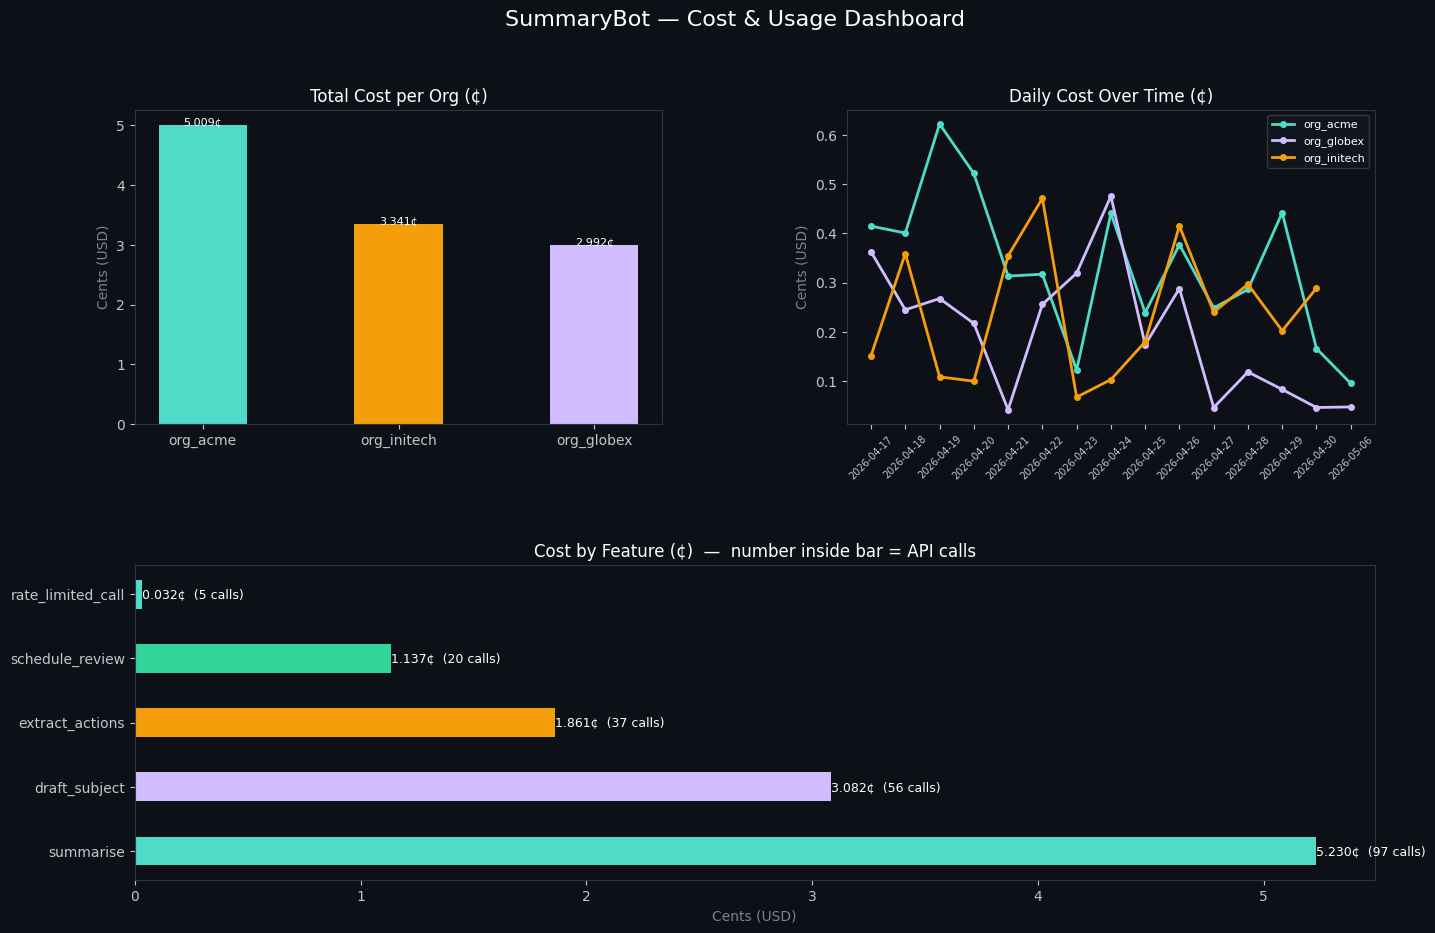

Dashboard saved to /tmp/summarybot_dashboard.png


In [13]:
# ── Seed extra usage data for a richer dashboard ──────────────────────────
# Simulate two weeks of usage across 3 orgs and 4 features

import random
from datetime import datetime, timedelta

random.seed(42)  # reproducible

# Add a third org for the dashboard
with _DB:
    _DB.execute("INSERT OR IGNORE INTO orgs (id, name, plan) VALUES (?, ?, ?)",
                ("org_initech", "Initech LLC", "free"))

DEMO_ORGS     = ["org_acme", "org_globex", "org_initech"]
DEMO_FEATURES = ["summarise", "draft_subject", "extract_actions", "schedule_review"]
DEMO_MODEL    = "claude-haiku-4-5-20251001"

# Weights simulate realistic usage patterns:
# summarise is most common, schedule_review is rare
FEATURE_WEIGHTS = [0.50, 0.25, 0.15, 0.10]

rows_to_insert = []
base_date = datetime(2026, 4, 17)  # two weeks ago

for day_offset in range(14):
    call_date = base_date + timedelta(days=day_offset)
    for _ in range(random.randint(8, 20)):  # 8-20 calls per day across all orgs
        org_id  = random.choice(DEMO_ORGS)
        feature = random.choices(DEMO_FEATURES, weights=FEATURE_WEIGHTS)[0]
        in_tok  = random.randint(80, 400)
        out_tok = random.randint(30, 150)
        cost    = compute_cost(DEMO_MODEL, in_tok, out_tok)
        rows_to_insert.append((
            org_id, f"user_{random.randint(1,5)}", feature, DEMO_MODEL,
            in_tok, out_tok, cost, call_date.strftime("%Y-%m-%d")
        ))

with _DB:
    _DB.executemany(
        """INSERT INTO usage_logs
           (org_id, user_id, feature, model, input_tokens, output_tokens, cost_usd, created_at)
           VALUES (?, ?, ?, ?, ?, ?, ?, ?)""",
        rows_to_insert
    )

print(f"Inserted {len(rows_to_insert)} demo rows into usage_logs")

# ── Fetch aggregated data for the dashboard ────────────────────────────────
df_org = pd.read_sql_query(
    "SELECT org_id, SUM(cost_usd) as total_cost, SUM(input_tokens+output_tokens) as total_tokens "
    "FROM usage_logs GROUP BY org_id ORDER BY total_cost DESC",
    _DB
)

df_time = pd.read_sql_query(
    "SELECT DATE(created_at) as day, org_id, SUM(cost_usd) as daily_cost "
    "FROM usage_logs GROUP BY day, org_id ORDER BY day",
    _DB
)

df_feature = pd.read_sql_query(
    "SELECT feature, SUM(cost_usd) as cost, COUNT(*) as calls "
    "FROM usage_logs GROUP BY feature ORDER BY cost DESC",
    _DB
)

# ── Multi-panel dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor="#0d1117")
fig.suptitle("SummaryBot — Cost & Usage Dashboard", color="white", fontsize=16, y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])  # cost per org
ax2 = fig.add_subplot(gs[0, 1])  # tokens over time
ax3 = fig.add_subplot(gs[1, :])  # cost per feature (full width)

ORG_COLORS = {"org_acme": "#4fdbc8", "org_globex": "#d0bcff", "org_initech": "#f59e0b"}
FEAT_COLORS = ["#4fdbc8", "#d0bcff", "#f59e0b", "#34d399"]

# Panel 1: Cost per org (bar)
ax1.set_facecolor("#0d1117")
bar_colors = [ORG_COLORS.get(o, "#768497") for o in df_org["org_id"]]
bars = ax1.bar(df_org["org_id"], df_org["total_cost"] * 100,  # show in centidollars
               color=bar_colors, width=0.45)
ax1.set_title("Total Cost per Org (¢)", color="white")
ax1.set_ylabel("Cents (USD)", color="#768497")
ax1.tick_params(colors="#c4c6cc")
for spine in ax1.spines.values(): spine.set_color("#273647")
for bar, val in zip(bars, df_org["total_cost"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val*100:.3f}¢", ha="center", color="white", fontsize=8)

# Panel 2: Daily cost over time (line chart, one line per org)
ax2.set_facecolor("#0d1117")
for org_id, group in df_time.groupby("org_id"):
    color = ORG_COLORS.get(org_id, "#768497")
    ax2.plot(group["day"], group["daily_cost"] * 100, label=org_id,
             color=color, linewidth=2, marker="o", markersize=4)
ax2.set_title("Daily Cost Over Time (¢)", color="white")
ax2.set_ylabel("Cents (USD)", color="#768497")
ax2.tick_params(colors="#c4c6cc", axis="both")
ax2.tick_params(axis="x", rotation=45, labelsize=7)
for spine in ax2.spines.values(): spine.set_color("#273647")
ax2.legend(labelcolor="white", framealpha=0.2, facecolor="#1c2b3c", fontsize=8)

# Panel 3: Cost per feature + call count (horizontal bar, full width)
ax3.set_facecolor("#0d1117")
bars3 = ax3.barh(df_feature["feature"], df_feature["cost"] * 100,
                  color=FEAT_COLORS[:len(df_feature)], height=0.45)
ax3.set_title("Cost by Feature (¢)  —  number inside bar = API calls", color="white")
ax3.set_xlabel("Cents (USD)", color="#768497")
ax3.tick_params(colors="#c4c6cc")
for spine in ax3.spines.values(): spine.set_color("#273647")
for bar, (_, row) in zip(bars3, df_feature.iterrows()):
    ax3.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
             f"{row['cost']*100:.3f}¢  ({int(row['calls'])} calls)",
             va="center", color="white", fontsize=9)

plt.savefig("/tmp/summarybot_dashboard.png", dpi=120, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("Dashboard saved to /tmp/summarybot_dashboard.png")

---
## Part 9 — How This Maps to ARIA Phase 4

Every concept in this notebook has a direct counterpart in the ARIA production build:

```
This notebook (SummaryBot)              ARIA Phase 4
────────────────────────────────────────────────────────────────────────────
SQLite usage_logs table            →    PostgreSQL usage_logs (Supabase)
                                        — same schema, production-grade storage

compute_cost() + log_usage()       →    UsageMiddleware in FastAPI
                                        — fires on every /api/v1/* request

metered_call() wrapper             →    All LLM calls go through aria.llm.call()
                                        — logs usage, enforces tenant budget

create_access_token / verify_token →    FastAPI JWT dependency (Depends(get_current_user))
                                        — every protected endpoint requires a valid JWT

generate_api_key()                 →    /api/v1/keys POST endpoint
                                        — org admins can issue keys for integrations

ORG_CONTEXTS dict                  →    Org row in database (system_prompt column)
                                        — multi-tenant isolation is automatic

ask_with_tenant_context()          →    Each agent reads system_prompt from org row
                                        — no shared global state

call_with_timeout() / asyncio      →    All FastAPI routes are async
                                        — timeout set per endpoint in config.py

call_with_fallback()               →    FALLBACK_MODEL env var in config.py
                                        — automatically used when primary fails

cached_call() TTL dict             →    Redis cache keyed on (org_id, prompt_hash)
                                        — TTL from org plan (longer for enterprise)

client.messages.stream()           →    /api/v1/summarise/stream endpoint
                                        — FastAPI StreamingResponse + SSE

MCP_TOOLS + run_mcp_agent()        →    ARIA MCP agent node in LangGraph
                                        — Gmail MCP for proposal delivery emails
                                        — Calendar MCP for trial kickoff meetings

TokenBucket per user               →    Redis token bucket per (org_id, user_id)
                                        — rate limits enforced in FastAPI middleware

Cost dashboard (matplotlib)        →    /admin/dashboard React page
                                        — reads from usage_logs via API
```

---
## Summary

| Concept | One-line description |
|---------|---------------------|
| **Usage metering** | Log every LLM call's token counts and cost to a database, keyed by org and user |
| **compute_cost()** | `(input_tokens / 1M) × input_price + (output_tokens / 1M) × output_price` |
| **JWT** | Stateless signed token carrying user claims — server verifies with secret, no DB hit |
| **API key** | Long random string — simpler than JWT, better for machine-to-machine use |
| **Multi-tenancy** | Each org gets an isolated system prompt and data scope — no shared state across orgs |
| **Timeout guard** | `asyncio.wait_for` cancels a slow LLM call after a deadline |
| **Fallback model** | Try primary model; on failure, retry with a cheaper/faster backup |
| **Response cache** | SHA-256 the prompt as a key; skip the API call if a fresh cached result exists |
| **Streaming (SSE)** | `client.messages.stream()` yields tokens as they are generated — wraps in `StreamingResponse` for FastAPI |
| **MCP** | Standard protocol for LLMs to call external APIs (Gmail, Calendar) through a separate server |
| **Token bucket** | Rate limiter: tokens refill continuously up to capacity; each call drains a fixed amount |
| **Cost dashboard** | Aggregate usage_logs by org, day, and feature to visualise spend and spot runaway costs |

---

### What to explore next

1. **Redis-backed rate limiter** — replace the in-memory `_USER_BUCKETS` dict with Redis so limits persist across app restarts and scale across multiple FastAPI workers  
2. **Live Gmail MCP auth** — set up the `mcp__claude_ai_Gmail` server (already in your available tools) and replace the simulated handlers with real OAuth tokens  
3. **Budget alerts** — add a `monthly_budget_usd` column to `orgs` and trigger a Slack message when `SUM(cost_usd) > 0.8 * monthly_budget`  
4. **Prompt compression** — reduce input token costs by summarising long conversation histories before injecting them into new requests  
5. **Semantic cache** — instead of exact prompt hash, embed the prompt and find cache hits within cosine similarity > 0.95 (reduces cache misses on minor paraphrases)